### 

# Netflix_data_Analysis

## Introduction

Netflix, leader mondial du divertissement en ligne, a revolutionné la manière dont nous consommons les films et les series. Depuis sa création en 1997 jusqu'a sa domination actuelle du marche du streaming, la plateforme s'appuie massivement sur les données et l'intelligence artificielle pour personnaliser l'experience de ses utilisateurs.

Ce projet a pour objectif de réaliser une analyse exploratoire du catalogue Netflix, en s'appuyant sur un jeu de données datant de septembre 2021.

L'analyse est menée dans un environnement Jupyter Notebook, en utilisant principalement les bibliothqèues Pandas, Seaborn, Matplotlib et Missingno.



### sommaire
1. Chargement et exploration de la base de données  
2. Exploration Approfondie
3. Prétraitement des données
4. Visualisations graphiques avec Matplotlib et Seaborn
5. Conclusion

## Chargement et exploration de la base de données

## Import des bibliothéque

In [340]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as np
import plotly.express as px


## Chargement de la base de données

In [342]:
## Load the dataset
df = pd.read_csv('netflix_titles.csv')


## Exploration initiale des donéés

### 1 AFFICHAGES DES PREMIERES ET DERNIERES OBSERVATIONS

In [345]:
## first 5 rows
df.head() 


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [346]:
#last 5 rows
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


## 2 Informations du dataset


In [348]:
#dataset info 
df.info

<bound method DataFrame.info of      show_id     type                  title         director  \
0         s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV Show          Blood & Water              NaN   
2         s3  TV Show              Ganglands  Julien Leclercq   
3         s4  TV Show  Jailbirds New Orleans              NaN   
4         s5  TV Show           Kota Factory              NaN   
...      ...      ...                    ...              ...   
8802   s8803    Movie                 Zodiac    David Fincher   
8803   s8804  TV Show            Zombie Dumb              NaN   
8804   s8805    Movie             Zombieland  Ruben Fleischer   
8805   s8806    Movie                   Zoom     Peter Hewitt   
8806   s8807    Movie                 Zubaan      Mozez Singh   

                                                   cast        country  \
0                                                   NaN  United States   
1     Ama Qamata, Khosi Ngema, Gail Mab

In [349]:
#show index type
print(type(df.index))


<class 'pandas.core.indexes.range.RangeIndex'>


In [350]:
df.info(memory_usage='deep')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 7.8 MB


In [351]:
#dimensions of the dataset
df.shape

(8807, 12)

In [352]:
#show the columns 
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [353]:
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

## Exploration approfondie

###  Analyse des données Manquantes

### a Pourcentage des données manquantes 

In [357]:
df.isnull().sum() / len(df) * 100 

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64

### b Visualisation des données manquates 

<Axes: >

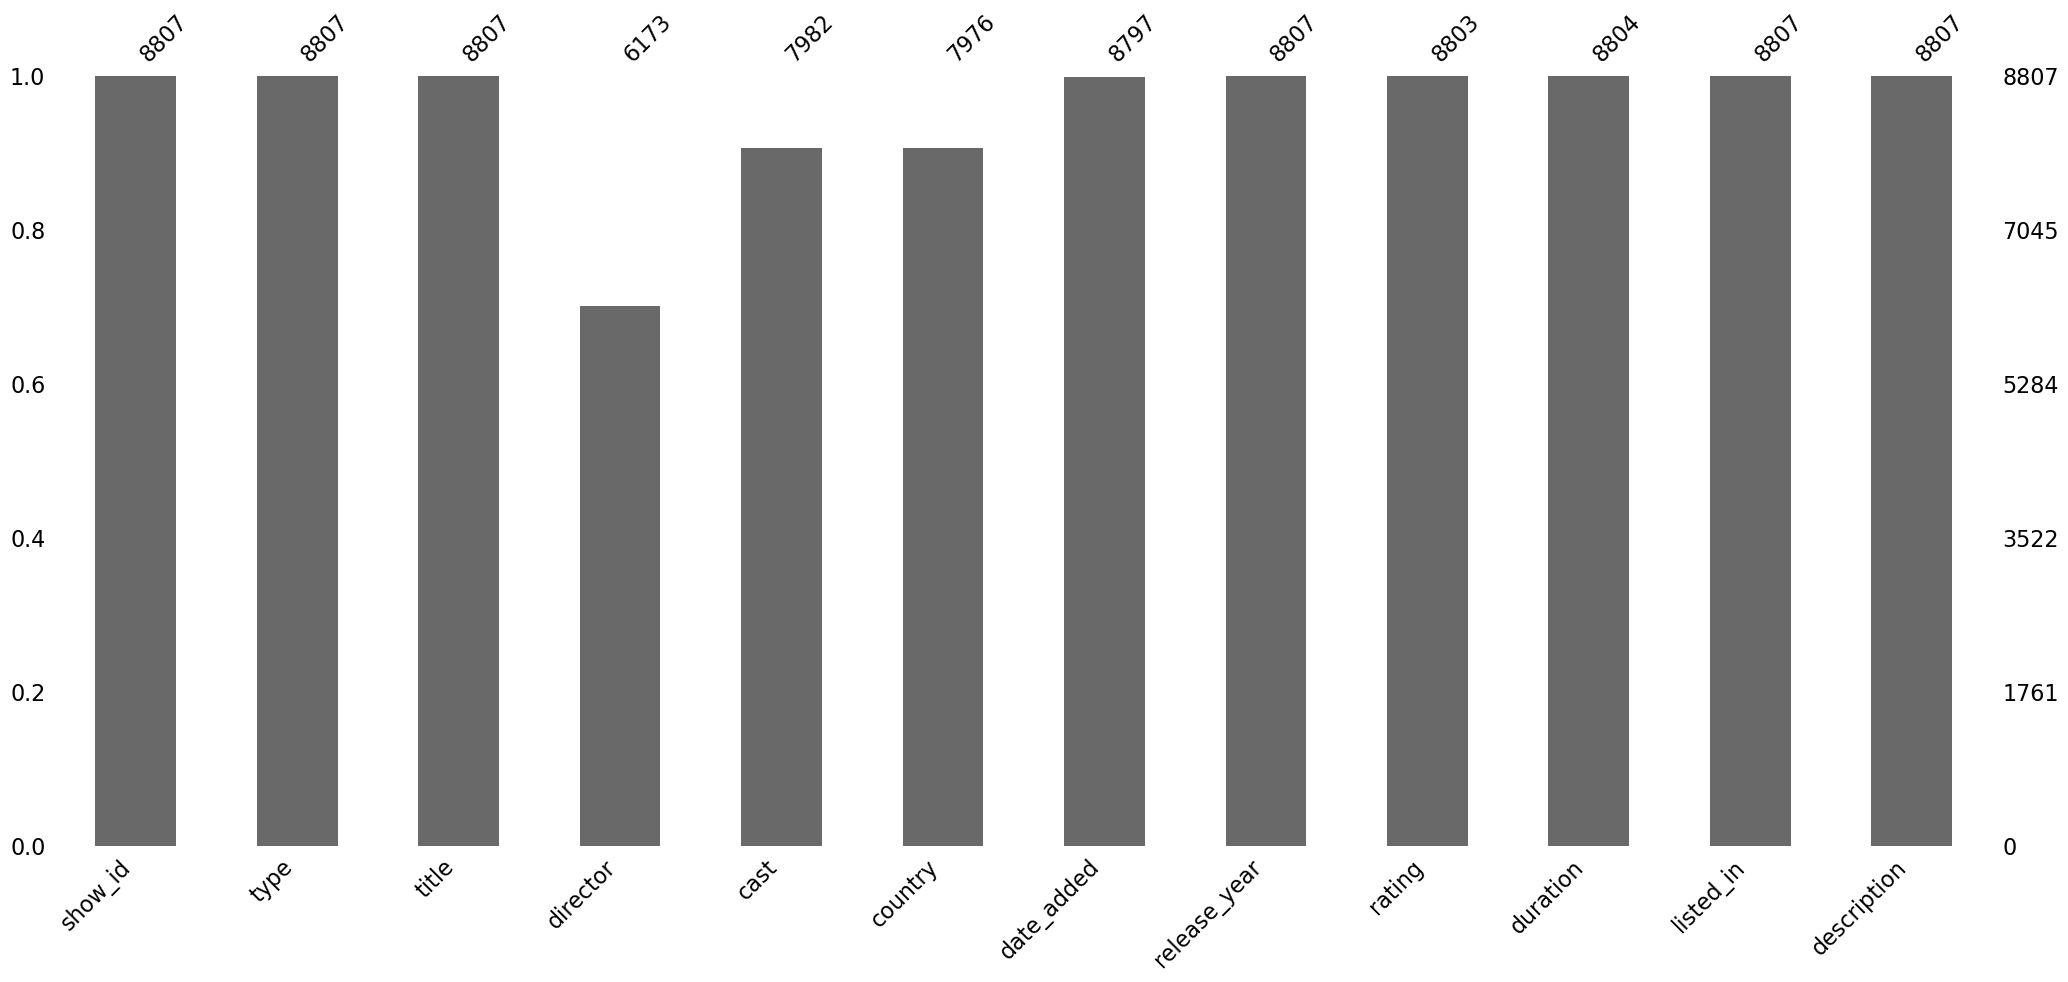

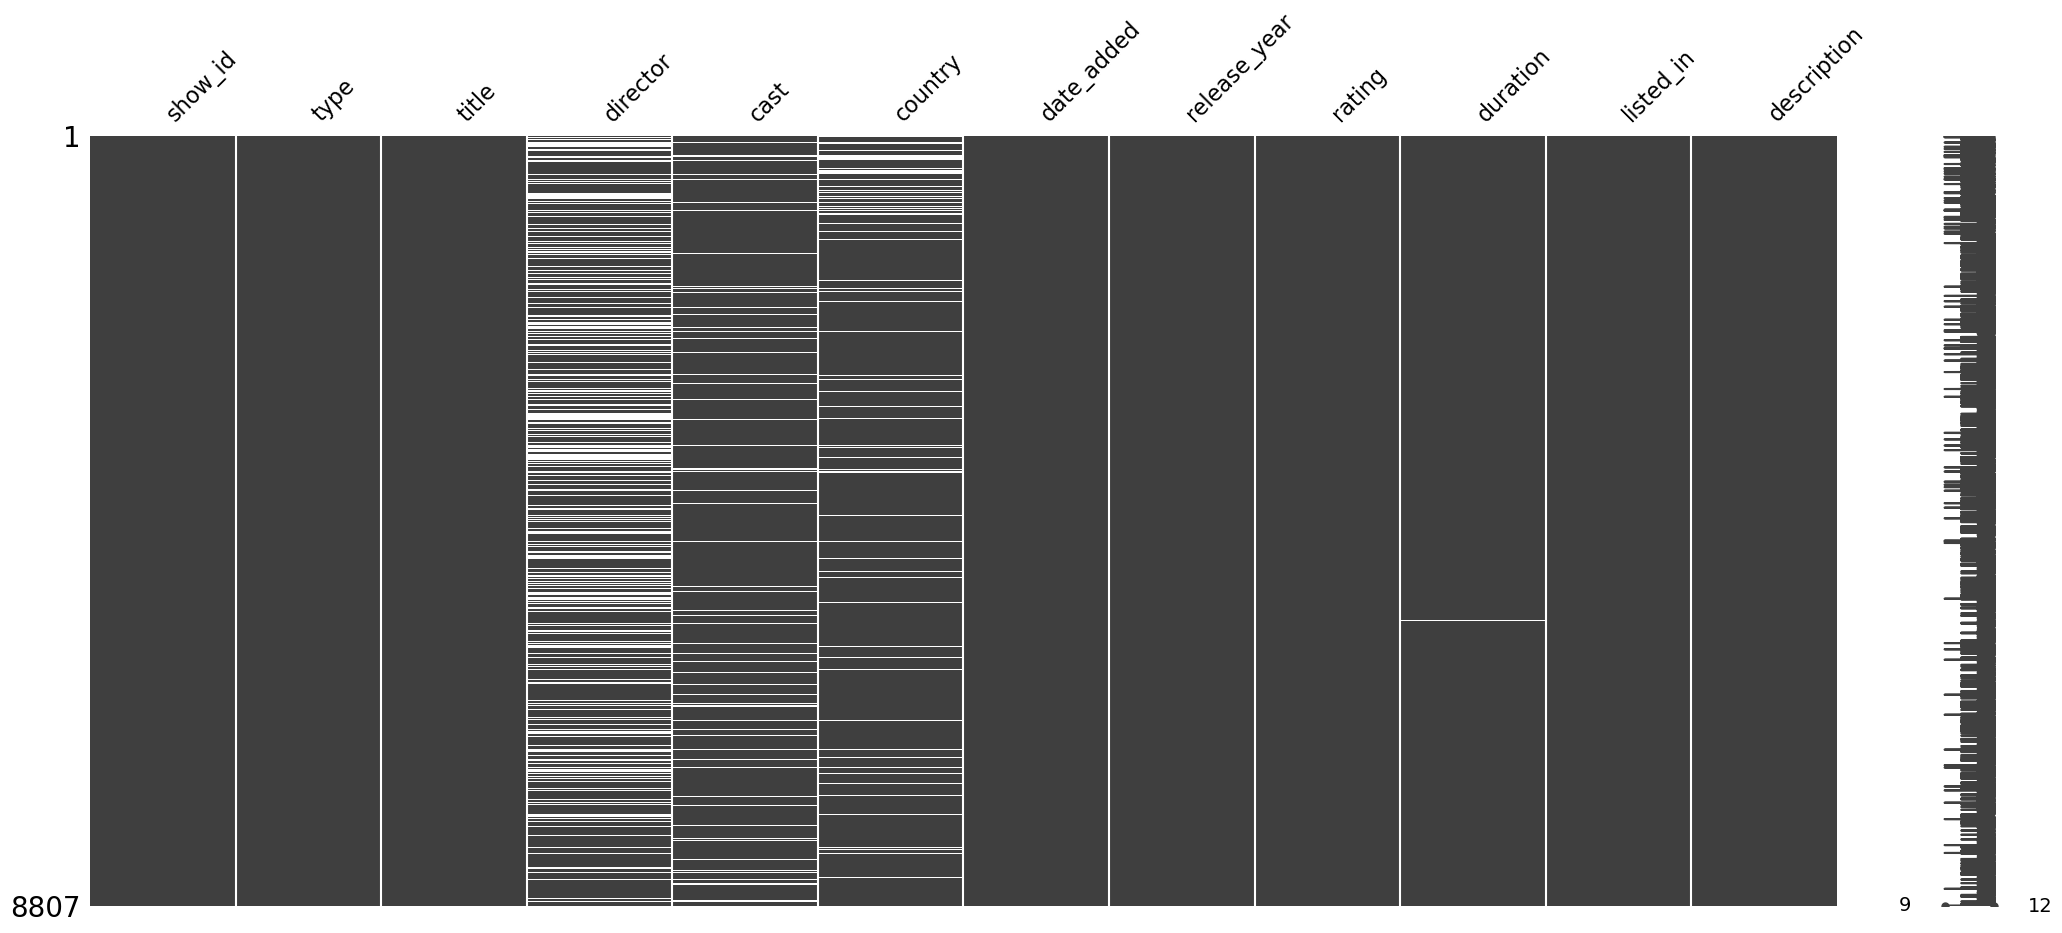

In [359]:
import missingno as msno
msno.bar(df)                       
msno.matrix(df)

### Première Analyse

Le jeu de données utilisé provient du fichier netflix_titles.csv, lors de la première inspection des données,on a observé qu'il contient des informations sur les films, les séries, les documentaires, et autres productions disponibles sur la plateforme Netflix. Le dataset comporte 8807 lignes et 12 colonnes, comprenant des informations telles que le titre du contenu, son type (film, série, documentaire), son réalisateur, son casting, le pays d’origine, la date d’ajout au catalogue, la durée, le rating, et les genres.
Les colonnes date_added et release_year nécessitent des transformations pour être utilisées dans des analyses temporelles.

La colonne duration (durée des films et séries) contient à la fois des chiffres (minutes) et des types (saison(s) pour les séries).

On observe la presence de valeurs manquantes notamment dans director(29.9%), cast(9.3%), country(9.4%) et date_added(0.11%).

Un graphique Missingno permet de visualiser precisement la proportion de donnees manquantes.
Ces données manquantes peuvent biaiser certaines analyses (ex. étude de la répartition des réalisateurs ou des pays producteurs).

Il faut envisager des méthodes de gestion de ces valeurs manquantes :  

Suppression    

Remplissage avec une valeur par défaut (ex : “Inconnu”)    

Ou exclusion de l’analyse concernée.

###  Observation Aléatoire

In [363]:
df.sample(1)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
7044,s7045,Movie,I Don't Know How She Does It,Douglas McGrath,"Sarah Jessica Parker, Pierce Brosnan, Greg Kin...",United States,"March 23, 2019",2011,PG-13,89 min,Comedies,"In this affable yuppie comedy, Kate Reddy is a..."


### Information sur l'oeuvre "Catch Me If You Can"

In [365]:
df[df['title'] == "Catch Me If You Can"]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
329,s330,Movie,Catch Me If You Can,Steven Spielberg,"Leonardo DiCaprio, Tom Hanks, Christopher Walk...","United States, Canada","August 1, 2021",2002,PG-13,142 min,Dramas,An FBI agent makes it his mission to put cunni...


### Film le plus récent du dataset

In [367]:
films = df[df['type'] == 'Movie']
films.sort_values(by='release_year', ascending=False)[['title', 'release_year']].head(1)

,title,release_year
570,Dynasty Warriors,2021


### Serie la plus récente du dataset

In [369]:
series = df[df['type'] == 'TV Show']
series.sort_values(by='release_year', ascending=False)[['title', 'release_year']].head(1)

,title,release_year
1,Blood & Water,2021


## Réalisateur le plus Prolifique

In [371]:
directors_counts = df['director'].value_counts()

directors_counts[directors_counts > 1].head(10)

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Marcus Raboy              16
Suhas Kadav               16
Jay Karas                 14
Cathy Garcia-Molina       13
Martin Scorsese           12
Youssef Chahine           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64

### L'Année la plus prolifique au niveau des films

In [373]:
films['release_year'].value_counts().idxmax()

2017

### L'Année la plus prolifique au niveau des films

In [375]:
series['release_year'].value_counts().idxmax()

2020

## Prétraitement des données

In [377]:
# Nettoyage de la date
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')

La colonne date_added a été convertie en format datetime pour faciliter les analyses temporelles, notamment pour extraire l’année d’ajout des contenus au catalogue.

In [379]:
# Nettoyage de la durée (films et séries)
df['duration_int'] = df['duration'].str.extract(r'(\d+)').astype(float)
df['duration_type'] = df['duration'].str.extract('([a-zA-Z ]+)', expand=False).str.strip()


In [380]:
# Transformation de listed_in en liste
df['listed_in'] = df['listed_in'].str.split(', ')

Plusieurs transformations ont été réalisées pour rendre les données exploitables.
La colonne date_added a été convertie en format datetime pour faciliter les analyses temporelles, notamment pour extraire l’année d’ajout des contenus au catalogue.
La colonne duration a été séparée en deux nouvelles colonnes :
duration_int pour la durée en minutes des films,
duration_type pour le type de durée (saison(s) pour les séries).

Cela permet de mieux gérer la distinction entre les films et les séries
La colonne listed_in, qui contient une liste de genres pour chaque contenu, a été transformée en liste, ce qui permet de mieux manipuler et analyser les genres par contenu


In [382]:
# Exploiration 
print("Types uniques :", df['type'].unique())
print("Pays uniques :", df['country'].dropna().unique())
print("Années de sortie uniques :", df['release_year'].unique())
print("Classifications uniques :", df['rating'].dropna().unique())
print("Genres uniques :", df['listed_in'].dropna().astype(str).unique())


Types uniques : ['Movie' 'TV Show']
Pays uniques : ['United States' 'South Africa' 'India'
 'United States, Ghana, Burkina Faso, United Kingdom, Germany, Ethiopia'
 'United Kingdom' 'Germany, Czech Republic' 'Mexico' 'Turkey' 'Australia'
 'United States, India, France' 'Finland' 'China, Canada, United States'
 'South Africa, United States, Japan' 'Nigeria' 'Japan'
 'Spain, United States' 'France' 'Belgium' 'United Kingdom, United States'
 'United States, United Kingdom' 'France, United States' 'South Korea'
 'Spain' 'United States, Singapore' 'United Kingdom, Australia, France'
 'United Kingdom, Australia, France, United States'
 'United States, Canada' 'Germany, United States'
 'South Africa, United States' 'United States, Mexico'
 'United States, Italy, France, Japan'
 'United States, Italy, Romania, United Kingdom'
 'Australia, United States' 'Argentina, Venezuela'
 'United States, United Kingdom, Canada' 'China, Hong Kong' 'Russia'
 'Canada' 'Hong Kong' 'United States, China, Hong 

## Visualisations avec Matplotlib et Seaborn

### Répartitions des films et séries

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


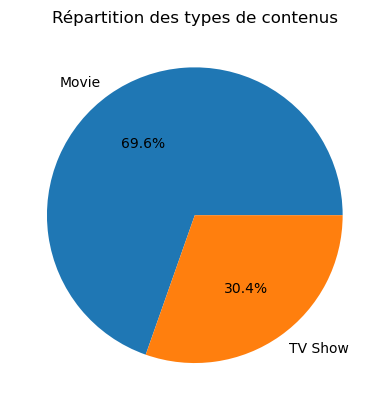

In [385]:
print(df['type'].value_counts())
df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Répartition des types de contenus')
plt.ylabel("")
plt.show()


La majorité des œuvres du catalogue sont des films (environ 70 %), contre 30 % pour les séries.

### Répartion des oeuvres par pays

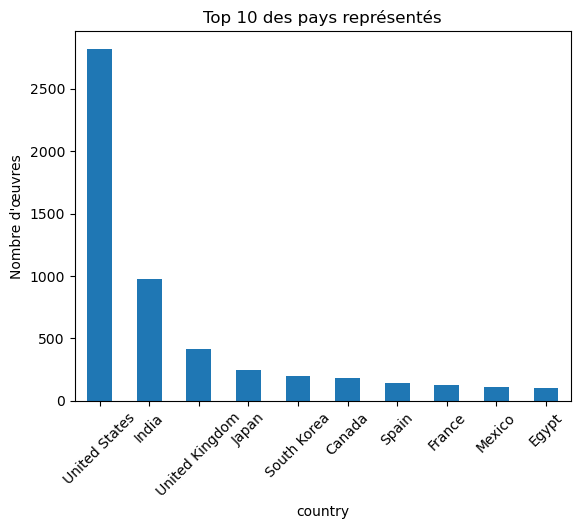

In [388]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 des pays représentés')
plt.ylabel('Nombre d\'œuvres')
plt.xticks(rotation=45)
plt.show()

Les œuvres proviennent principalement des États-Unis, suivis de l'Inde, du Royaume-Uni et du Canada. La France occupe la huitième place.

### Répartion des oeuvres par années de sortie

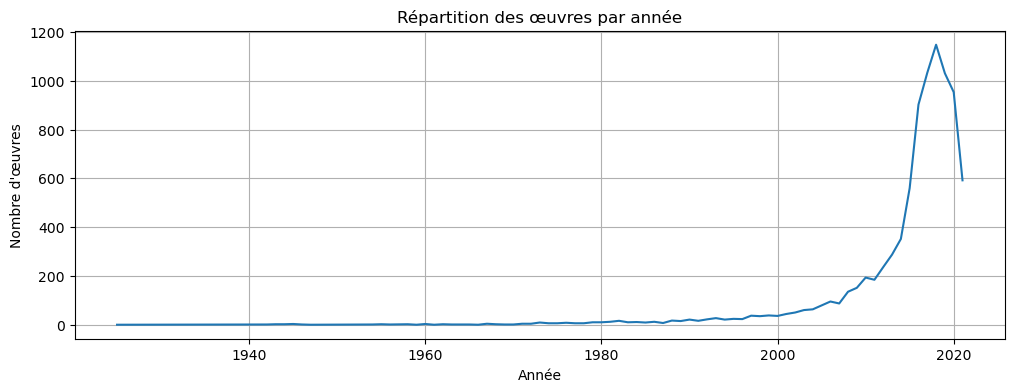

In [391]:
df['release_year'].value_counts().sort_index().plot(kind='line', figsize=(12, 4))
plt.title('Répartition des œuvres par année')
plt.xlabel("Année")
plt.ylabel("Nombre d'œuvres")
plt.grid(True)
plt.show()

Les films et séries sont principalement issus des années 2000 à 2020, avec un pic autour de 2018. Cela reflète l'évolution de la stratégie de production de contenus originaux de Netflix.

### Répartion des rating

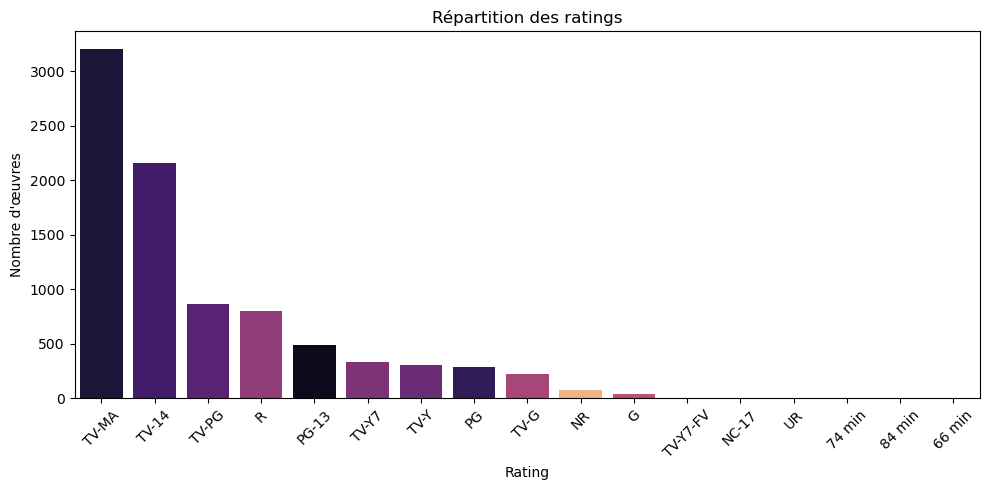

In [394]:


# Configuration de la taille de la figure
plt.figure(figsize=(10, 5))

# Création du countplot
sns.countplot(
    data=df,
    x='rating',
    order=df['rating'].value_counts().index,
    hue='rating',  
    palette='magma',
    legend=False   
)

# Personnalisation du graphique
plt.title("Répartition des ratings")
plt.xticks(rotation=45)
plt.xlabel("Rating")
plt.ylabel("Nombre d'œuvres")
plt.tight_layout()
plt.show()


Les classifications les plus fréquentes sont TV-MA, TV-14, R, ce qui indique une majorité de contenus pour un public adolescent ou adulte.

### Répartion des durées de films du dataset

count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_minutes, dtype: float64


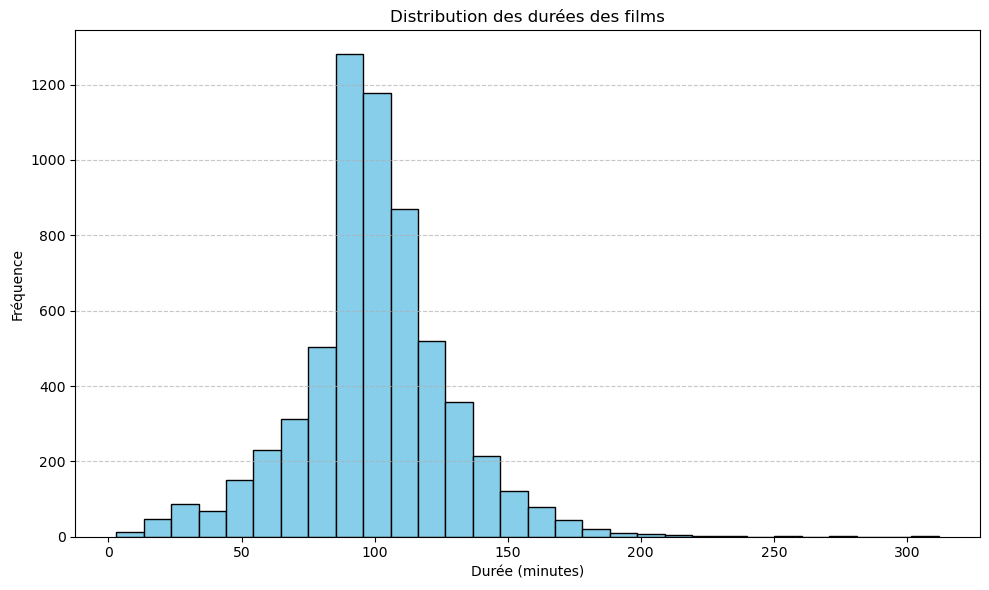

In [397]:
# Filtrer les films et faire une copie 
movies_df = df[df['type'] == 'Movie'].copy()

# Extraction des minutes comme float en utilisant une raw string
movies_df['duration_minutes'] = movies_df['duration'].str.extract(r'(\d+)').astype(float)

# Statistiques descriptives
print(movies_df['duration_minutes'].describe())

# Visualisation
plt.figure(figsize=(10, 6))
movies_df['duration_minutes'].plot(kind='hist', bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution des durées des films")
plt.xlabel("Durée (minutes)")
plt.ylabel("Fréquence")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Analyse :  
La durée des films est concentrée entre 70 et 120 minutes, avec un pic aux alentours de 90 minutes.

Très peu de films durent moins de 40 minutes ou plus de 150 minutes.

On observe une distribution asymétrique, légèrement étalée à droite (quelques films très longs).

### Répartion du nombre de saisons par serie du dataset

count    2676.000000
mean        1.764948
std         1.582752
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        17.000000
Name: seasons, dtype: float64


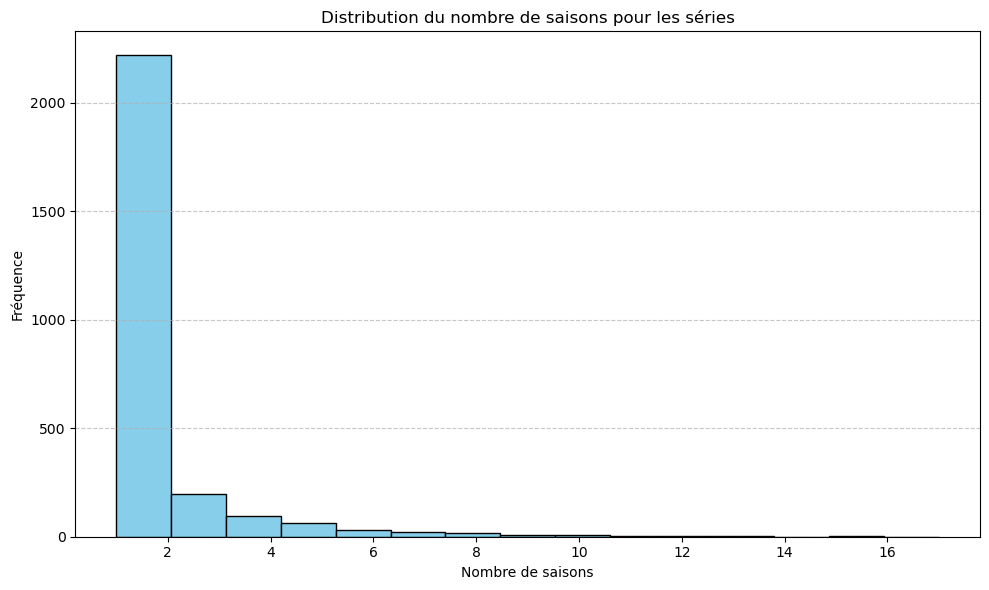

In [400]:
series_df = df[df['type'] == 'TV Show'].copy()

# Extraction du nombre de saisons à partir de la colonne "duration"
series_df['seasons'] = series_df['duration'].str.extract(r'(\d+)').astype(float)

# Statistiques descriptives
print(series_df['seasons'].describe())

# Visualisation
plt.figure(figsize=(10, 6))
series_df['seasons'].plot(kind='hist', bins=15, color='skyblue', edgecolor='black')
plt.title("Distribution du nombre de saisons pour les séries")
plt.xlabel("Nombre de saisons")
plt.ylabel("Fréquence")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Analyse :  
La majorité écrasante des séries dans le catalogue Netflix ont une seule saison.  

On observe une forte chute dès la deuxième saison, et le nombre de séries diminue drastiquement avec l’augmentation du nombre de saisons.  

Très peu de séries dépassent les 5 saisons, et les séries avec plus de 10 saisons sont extrêmement rares.  


### Répartion des genres d'oeuvres du dataset (top 10)

Top 10 genres :
International Movies: 2752
Dramas: 2427
Comedies: 1674
International TV Shows: 1351
Documentaries: 869
Action & Adventure: 859
TV Dramas: 763
Independent Movies: 756
Children & Family Movies: 641
Romantic Movies: 616


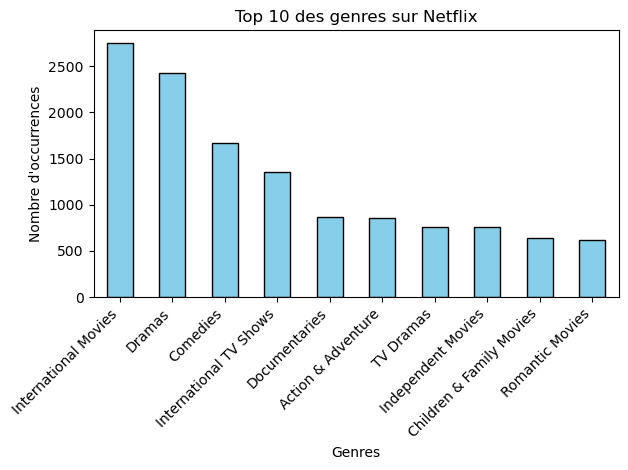

In [403]:
from collections import Counter

# Aplatir toutes les listes de genres
all_genres = [genre for sublist in df['listed_in'].dropna() for genre in sublist]

# Compter les occurrences de chaque genre
genre_counts = Counter(all_genres)
top_genres = dict(genre_counts.most_common(10))

print("Top 10 genres :")
for genre, count in top_genres.items():
    print(f"{genre}: {count}")

pd.Series(top_genres).plot(
    kind='bar',
    title="Top 10 des genres sur Netflix",
    color='skyblue',
    edgecolor='black'
)

plt.ylabel("Nombre d'occurrences")
plt.xlabel("Genres")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Les genres les plus représentés sont :

Pour les films : Dramas, International Movies, Comedies

Pour les séries : International TV Shows, TV Dramas, TV Comedies

### Répartion par mois d'ajout 

month_added
January      738
February     563
March        742
April        764
May          632
June         728
July         827
August       755
September    770
October      760
November     705
December     813
Name: count, dtype: int64


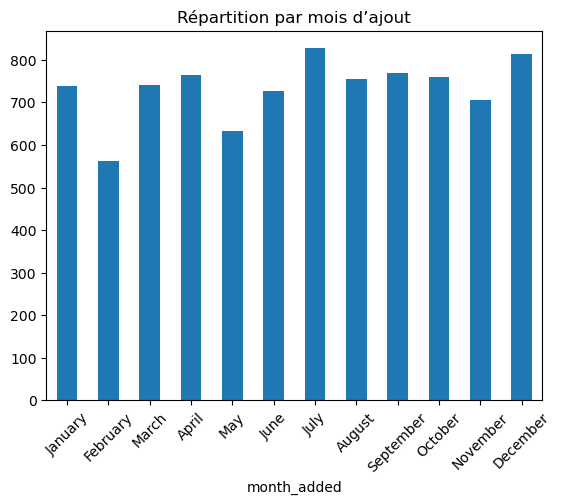

In [406]:
df['month_added'] = df['date_added'].dt.month_name()
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
print(df['month_added'].value_counts().reindex(month_order))
df['month_added'].value_counts().reindex(month_order).plot(kind='bar', title="Répartition par mois d’ajout")
plt.xticks(rotation=45)
plt.show()

### Répartion par date d'ajout 

period
2008-01      1
2008-02      1
2009-05      1
2009-11      1
2010-11      1
          ... 
2021-05    132
2021-06    207
2021-07    257
2021-08    178
2021-09    183
Freq: M, Name: count, Length: 108, dtype: int64


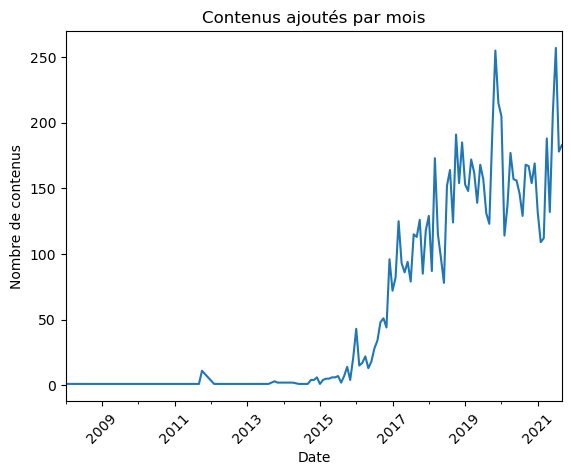

In [408]:
df['period'] = df['date_added'].dt.to_period('M')
print(df['period'].value_counts().sort_index())
df['period'].value_counts().sort_index().plot(kind='line', title="Contenus ajoutés par mois")
plt.xlabel("Date")
plt.ylabel("Nombre de contenus")
plt.xticks(rotation=45)
plt.show()

On remarque une forte augmentation de contenus à partir de 2017 avec des pics sur les dernières périodes de chaque année depuis cette date. 

### Top 10 des réalisateurs

director
Thierry Donard     5
Youssef Chahine    4
Jane Campion       3
Jalil Lespert      3
Olivier Assayas    3
Maroun Baghdadi    3
Sylvie Verheyde    2
Florent Bodin      2
Luc Vinciguerra    2
Ziad Doueiri       2
Name: count, dtype: int64


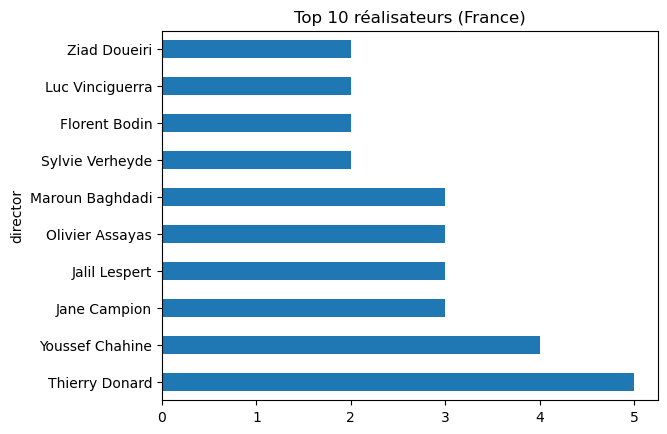

In [411]:
french_df = df[df['country'].str.contains('France', na=False)]
print(french_df['director'].value_counts().head(10))
french_df['director'].value_counts().head(10).plot(kind='barh', title="Top 10 réalisateurs (France)")
plt.show()

Le réalisateur avec le plus grand nombre d'œuvres réalisées en france dans le dataset est Thierry Donard avec 5 oeuvres réalisé.

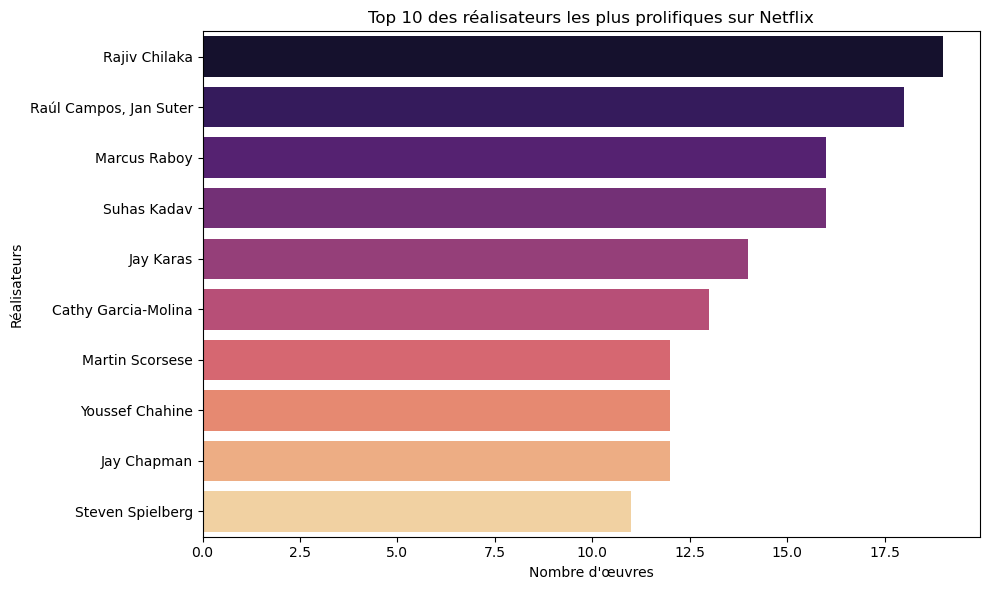

In [413]:
# Top 10 des réalisateurs les plus prolifiques
top_directors = df['director'].dropna().value_counts().head(10)
directors_df = top_directors.reset_index()
directors_df.columns = ['director', 'count']

plt.figure(figsize=(10, 6))
sns.barplot(data=directors_df, x='count', y='director', hue='director', legend=False, palette="magma")
plt.title("Top 10 des réalisateurs les plus prolifiques sur Netflix")
plt.xlabel("Nombre d'œuvres")
plt.ylabel("Réalisateurs")
plt.tight_layout()
plt.show()


les réalisateurs les plus prolifiques au niveau mondial sont Rajiv Shilaka(19 oeuvres)  et Raoul Campos(18 oeuvres).

### Films vs Series par pays

type                                                Movie  TV Show
country                                                           
, France, Algeria                                     1.0      0.0
, South Korea                                         0.0      1.0
Argentina                                            38.0     18.0
Argentina, Brazil, France, Poland, Germany, Den...    1.0      0.0
Argentina, Chile                                      2.0      0.0
Argentina, Chile, Peru                                1.0      0.0
Argentina, France                                     1.0      0.0
Argentina, France, United States, Germany, Qatar      1.0      0.0
Argentina, Italy                                      1.0      0.0
Argentina, Spain                                      7.0      1.0


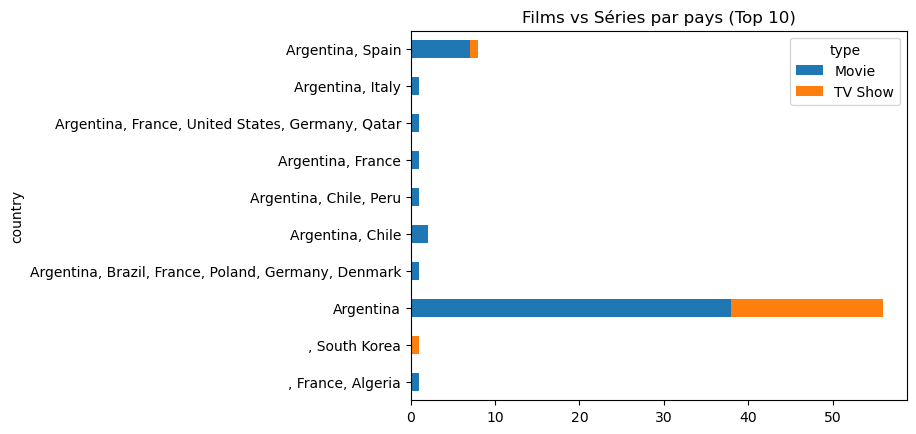

In [416]:
pivot_country_type = df.groupby(['country', 'type']).size().unstack().fillna(0).head(10)
print(pivot_country_type)
pivot_country_type.plot(kind='barh', stacked=True, title="Films vs Séries par pays (Top 10)")
plt.show()

## Observations Générales
Tendances des Contenus
Productions internationales : Netflix propose une grande variété de contenus internationaux, ce qui reflète sa stratégie d’expansion mondiale.

Dominance des films : Bien que la plateforme propose de nombreux contenus de séries, les films restent majoritaires dans le catalogue.

Public cible : La majorité des contenus sont destinés à un public adulte et adolescent, avec une prédominance de genres comme les drames et les comédies.

Tendance à la modernité : Les productions récentes dominent le catalogue, avec une nette augmentation des ajouts entre 2017 et 2019

##Implications pour la Recommandation de Contenus
Personnalisation : d'oté d’une large palette de genres et de types de contenus Netflix peut mettre en place des algorithmes de recommendation basé sur les préférences de ses utilisateurs. Ils peuvent ainsi recevoir des suggestions variées, allant des films aux séries, des contenus familiaux aux contenus plus adultes.

Tendances culturelles : netflix peut egalement exploiter Les préférences géographiques pour affiner les recommandations selon la région de l’utilisateur. Mais aussi pour cibler le types de contenus à prodruire pour conquérir  une zone géographique.



## Conclusion

L’analyse des données de Netflix révèle plusieurs tendances intéressantes sur le contenu disponible sur la plateforme. Nous avons exploré un dataset réel, nettoyé et transformé les données, puis réalisé des visualisations pour mieux comprendre la structure du catalogue Netflix. Les insights obtenus ouvrent la voie à des projets futurs, notamment dans le domaine de la recommandation de contenu et de la prédiction du succès des films et séries.

Ce projet constitue un pas important dans le développement de compétences en data science, en combinant manipulation de données, visualisation, analyse exploratoire et visualisations graphiques.

